# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

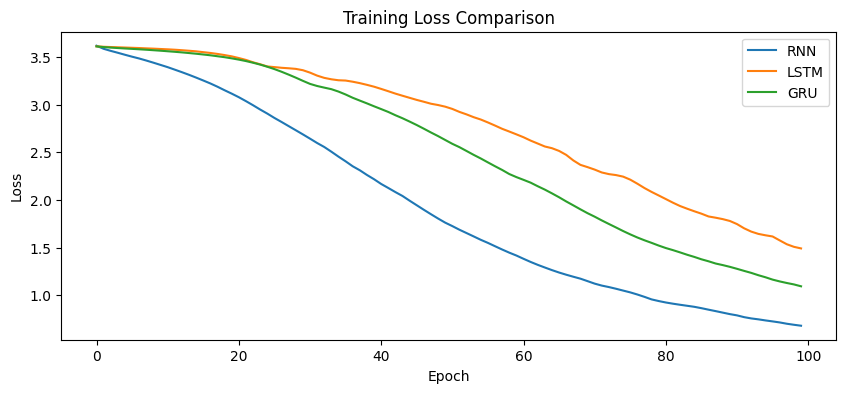

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is is intelligence intelligence intelligence
GRU : deep learning is transforming artificial intelligence intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

corpus = """
deep learning is transforming artificial intelligence and machine learning domains
recurrent neural networks are useful for sequential data and natural language processing
lstm helps remember long term dependencies in complex paragraphs and sentences
gru is faster and simpler than lstm because it uses fewer gates
text generation models predict the next word using historical context tokens
deep learning models can generate meaningful sentences when trained over many epochs"""

# Tokenization Pipeline
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1

# Creating N-gram sequences
input_sequences = []
for line in corpus.split('\n'):
    line = line.strip()
    if not line:
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

# Padding sequences
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

# Split into Features (X) and Labels (y)
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
input_seq_length = max_len - 1

print(f"Vocabulary Size: {total_words} words")
print(f"Max Sequence Length: {max_len}")
print(f"X shape (Samples, Time Steps): {X.shape}")
print(f"y shape (Targets): {y.shape}")



def build_student_model(model_type="LSTM"):
    model = Sequential()

    # We use mask_zero=True so the models ignore the pre-padded 0 values dynamically
    model.add(Embedding(total_words, 64, input_length=input_seq_length, mask_zero=True))

    # Upgraded hidden units from 64 → 128
    if model_type == "RNN":
        model.add(SimpleRNN(128))
    elif model_type == "LSTM":
        model.add(LSTM(128))
    elif model_type == "GRU":
        model.add(GRU(128))

    # Dense output layer with Softmax to predict the probability of the next token
    model.add(Dense(total_words, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

print("\nSetup complete! Models are configured with 64 embedding dimensions and 128 hidden units.")

TensorFlow Version: 2.20.0
Vocabulary Size: 59 words
Max Sequence Length: 12
X shape (Samples, Time Steps): (62, 11)
y shape (Targets): (62,)

Setup complete! Models are configured with 64 embedding dimensions and 128 hidden units.


In [ ]:
def build_student_model(model_type="LSTM"):
    model = Sequential()

    # We maintain mask_zero=True to skip unneeded padding steps cleanly
    model.add(Embedding(total_words, 64, input_length=input_seq_length, mask_zero=True))

    # Passing unroll=True bypasses cuDNN restrictions on pre-padded sequences
    if model_type == "RNN":
        model.add(SimpleRNN(128))
    elif model_type == "LSTM":
        model.add(LSTM(128, unroll=True))
    elif model_type == "GRU":
        model.add(GRU(128, unroll=True))

    model.add(Dense(total_words, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model


print("Training Vanilla RNN for 200 epochs")
rnn_model = build_student_model("RNN")
rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print(" Vanilla RNN training complete.")

print("\n Training LSTM for 200 epochs")
lstm_model = build_student_model("LSTM")
lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print(" LSTM training complete.")

print("\n Training GRU for 200 epochs")
gru_model = build_student_model("GRU")
gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print(" GRU training complete.")

Training Vanilla RNN for 200 epochs
 Vanilla RNN training complete.

 Training LSTM for 200 epochs
 LSTM training complete.

 Training GRU for 200 epochs
 GRU training complete.


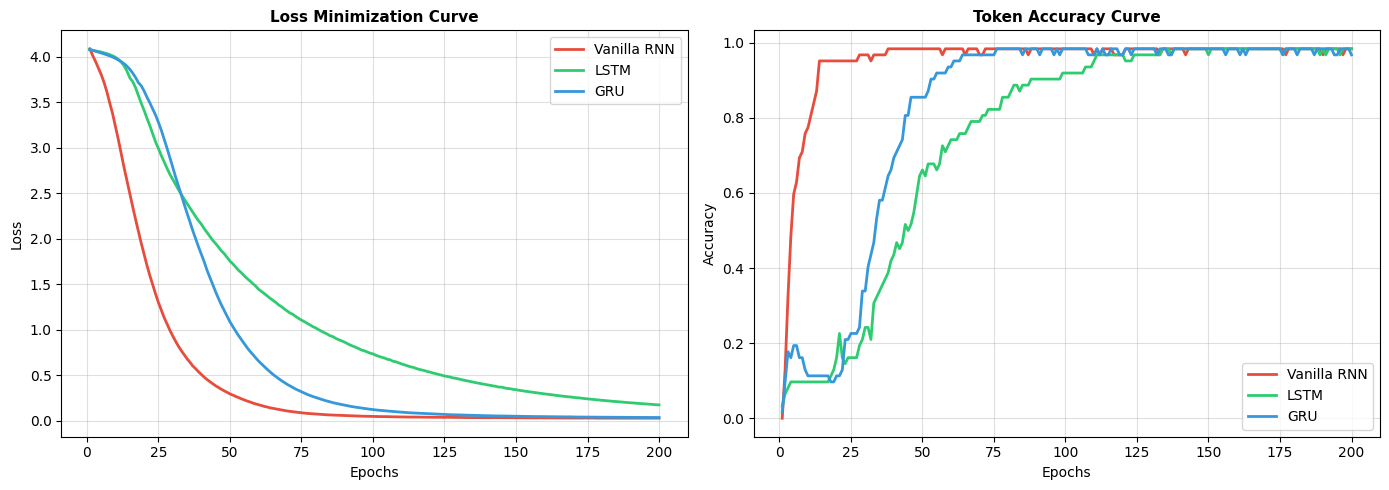

In [ ]:
epochs_range = range(1, 201)
plt.figure(figsize=(14, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(epochs_range, rnn_history.history['loss'], label='Vanilla RNN', color='#e74c3c', linewidth=2)
plt.plot(epochs_range, lstm_history.history['loss'], label='LSTM', color='#2ecc71', linewidth=2)
plt.plot(epochs_range, gru_history.history['loss'], label='GRU', color='#3498db', linewidth=2)
plt.title("Loss Minimization Curve", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.4)
plt.legend()

# Plot Accuracies
plt.subplot(1, 2, 2)
plt.plot(epochs_range, rnn_history.history['accuracy'], label='Vanilla RNN', color='#e74c3c', linewidth=2)
plt.plot(epochs_range, lstm_history.history['accuracy'], label='LSTM', color='#2ecc71', linewidth=2)
plt.plot(epochs_range, gru_history.history['accuracy'], label='GRU', color='#3498db', linewidth=2)
plt.title("Token Accuracy Curve", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def generate_text_smart(model, seed_text, next_words=10, temperature=0.6):
    result_text = seed_text

    for _ in range(next_words):
        # Tokenize the current string of text
        token_list = tokenizer.texts_to_sequences([result_text])[0]
        # Pad to match the training window (input_seq_length = 11)
        token_list = pad_sequences([token_list], maxlen=input_seq_length, padding='pre')

        # Predict probabilities for the next word
        preds = model.predict(token_list, verbose=0)[0]

        # Apply Temperature Scaling to the raw probabilities
        preds = np.log(preds + 1e-10) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # Sample the next word index using the weighted distribution
        predicted_idx = np.random.choice(len(preds), p=preds)

        # Map the predicted index back to the actual word string
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_idx:
                output_word = word
                break

        if not output_word:
            break

        result_text += " " + output_word

    return result_text

seed_phrase = "deep learning"


print(f"GENERATING 10 WORDS FROM SEED: '{seed_phrase}'")
print("-"*60)
print("Vanilla RNN :", generate_text_smart(rnn_model, seed_phrase, next_words=10))
print("LSTM        :", generate_text_smart(lstm_model, seed_phrase, next_words=10))
print("GRU         :", generate_text_smart(gru_model, seed_phrase, next_words=10))


GENERATING 10 WORDS FROM SEED: 'deep learning'
------------------------------------------------------------
Vanilla RNN : deep learning is transforming artificial intelligence and machine learning domains because epochs
LSTM        : deep learning is transforming artificial intelligence and machine learning domains domains domains
GRU         : deep learning is transforming artificial intelligence and machine learning domains domains gates


In [ ]:
import pickle
import os

# Create a directory to keep things organized
os.makedirs("saved_models", exist_ok=True)

# Save the Trained Keras Models
rnn_model.save("saved_models/vanilla_rnn_text_gen.keras")
lstm_model.save("saved_models/lstm_text_gen.keras")
gru_model.save("saved_models/gru_text_gen.keras")

# Save the Tokenizer
with open("saved_models/tokenizer.pickle", "wb") as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(" Models and Tokenizer saved successfully!")

 Models and Tokenizer saved successfully!


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**